In [1]:
import warnings
warnings. filterwarnings('ignore')

import pandas as pd
import numpy as np
from shapely.geometry import Point, LineString
from shapely.ops import transform
import matplotlib.pyplot as plt
import movingpandas as mpd
import pyproj

%matplotlib inline

In [2]:
#Transformation function to calculate degrees to m (WGS84 to RD)
wgs_deg = pyproj.CRS('EPSG:4326')
rd_m = pyproj.CRS('EPSG:28992')
deg_to_m = pyproj.Transformer.from_crs(wgs_deg, rd_m, always_xy=True).transform

In [3]:
#Transect that goes through the center of the lock chambers at the Volkerak
Volkerak_center_transect = LineString([Point(4.4082,51.6912),Point(4.4105,51.6896)])

length_chamber = 320 #meters

In [4]:
#Reading data
vessel_df = pd.read_csv('Volkerak_244010511.csv')

#Selecting data
vessel_df_volkerak = vessel_df[((vessel_df.latitude_deg > 51.65)&
                                (vessel_df.latitude_deg < 51.75)&
                                (vessel_df.longitude_deg > 4.25)&
                                (vessel_df.longitude_deg < 4.50))]

#Creating trajectory
trajectory = mpd.Trajectory(vessel_df_volkerak,traj_id='244010511',x='longitude_deg',y='latitude_deg',t='receivedAt')

#and adding distance
trajectory.add_distance()

#Getting geometry and geometry dataframe (in geopandas)
trajectory_linestring = trajectory.to_linestring()
trajectory_gdf = trajectory.to_point_gdf()

#Calculating the cumulative distance
trajectory_gdf['distance_cumulative'] = trajectory_gdf['distance'].cumsum()

#Transforming to RD
trajectory_linestring_m = transform(deg_to_m, trajectory_linestring)
Volkerak_center_transect_m = transform(deg_to_m, Volkerak_center_transect)

#Getting distance until vessel reaches lock center
intersection_point = trajectory_linestring_m.intersection(Volkerak_center_transect_m)
length_before_crossing = trajectory_linestring_m.project(intersection_point)

#Correct cumulative distance
trajectory_gdf.distance_cumulative = trajectory_gdf.distance_cumulative - length_before_crossing;

(np.float64(20333.40026909722), np.float64(20333.478631365742))

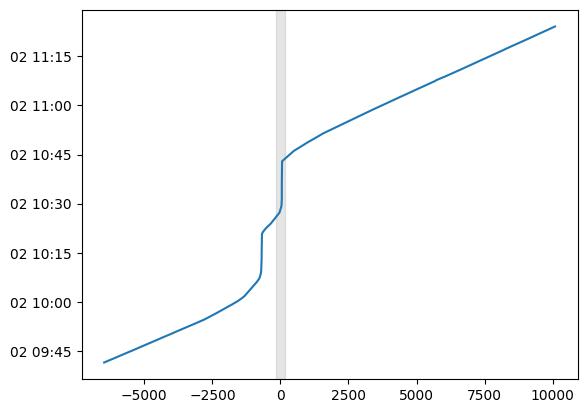

In [5]:
fig,ax = plt.subplots()
ax.plot(trajectory_gdf.distance_cumulative,trajectory_gdf.index)
ylim_min,ylim_max = ax.get_ylim()

ax.fill([-length_chamber/2,-length_chamber/2,length_chamber/2,length_chamber/2],[ylim_min,ylim_max,ylim_max,ylim_min],color='grey',zorder=-1,alpha=0.2)
ax.set_ylim(ylim_min,ylim_max)